# Smart Question Paper Analyzer

## Project Objective

This project analyzes a question paper using Natural Language Processing (NLP) techniques. It extracts useful information such as question types, topics, and question distribution.

## Technologies Used

- Python
- Natural Language Processing (NLP)
- NLTK
- Regular Expressions
- Jupyter Notebook

In [1]:
import re
from collections import Counter
from difflib import SequenceMatcher

In [2]:
STOPWORDS = {
    "the", "is", "a", "an", "of", "to", "in", "and",
    "for", "on", "with", "what", "are", "how", "why",
    "when", "where", "which", "who", "this", "that",
    "these", "those", "from", "by", "be", "as", "at",
    "or", "it", "its", "into", "their", "than",
    "explain", "write", "define", "give", "describe",
    "discuss", "state", "list", "using"
}

In [3]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def tokenize(text):
    return text.split()


def remove_stopwords(words):
    return [
        word for word in words
        if word not in STOPWORDS and len(word) > 2
    ]

In [4]:
def get_questions(text):
    lines = [
        line.strip()
        for line in text.splitlines()
        if line.strip()
    ]

    questions = []

    for line in lines:
        if re.match(r"^\s*(\d+[\.\)]|Q\.?\s*\d+)", line, re.IGNORECASE):
            questions.append(line)

    if not questions:
        parts = re.split(r"\?", text)

        for part in parts:
            part = part.strip()
            if part:
                questions.append(part + "?")

    return questions

In [5]:
def analyze_text(text):
    cleaned = clean_text(text)

    all_words = tokenize(cleaned)
    meaningful_words = remove_stopwords(all_words)
    frequency = Counter(meaningful_words)
    questions = get_questions(text)

    return all_words, meaningful_words, frequency, questions

In [8]:
with open("../dataset/Sample_question_paper.txt", "r", encoding="utf-8") as file:
    text = file.read()

print(text)

SMART QUESTION PAPER ANALYZER - SAMPLE QUESTION PAPER

Natural Language Processing

1. Define Natural Language Processing and explain its applications.
2. What is tokenization in Natural Language Processing?
3. Explain text preprocessing techniques used in NLP.
4. What is stop word removal? Explain its importance.
5. Define stemming and explain the stemming process.
6. What is lemmatization? Explain with an example.
7. Explain the difference between stemming and lemmatization.
8. What is part-of-speech tagging in NLP?
9. Explain named entity recognition and its applications.
10. What is sentiment analysis? Explain its working.
11. Define Natural Language Processing and discuss its applications.
12. Explain text preprocessing techniques used for NLP.
13. What is tokenization and why is it important?
14. Explain the role of stop word removal in text preprocessing.
15. What is text classification? Explain its applications in NLP.
16. Explain the difference between Natural Language Underst

In [7]:
import os

print(os.getcwd())

c:\Users\kriti\OneDrive\Desktop\NLP_Smart_Question_Paper_Analyzer\notebooks


In [9]:
all_words, meaningful_words, frequency, questions = analyze_text(text)

print("Total words:", len(all_words))
print("Meaningful words:", len(meaningful_words))
print("Total questions:", len(questions))

Total words: 189
Meaningful words: 94
Total questions: 20


In [10]:
print("Top 10 Keywords:")

for word, count in frequency.most_common(10):
    print(word, ":", count)

Top 10 Keywords:
natural : 8
language : 8
processing : 6
applications : 5
nlp : 5
text : 4
preprocessing : 3
word : 3
stemming : 3
question : 2


In [11]:
print("Questions found:")

for i, question in enumerate(questions, start=1):
    print(f"{i}. {question}")

Questions found:
1. 1. Define Natural Language Processing and explain its applications.
2. 2. What is tokenization in Natural Language Processing?
3. 3. Explain text preprocessing techniques used in NLP.
4. 4. What is stop word removal? Explain its importance.
5. 5. Define stemming and explain the stemming process.
6. 6. What is lemmatization? Explain with an example.
7. 7. Explain the difference between stemming and lemmatization.
8. 8. What is part-of-speech tagging in NLP?
9. 9. Explain named entity recognition and its applications.
10. 10. What is sentiment analysis? Explain its working.
11. 11. Define Natural Language Processing and discuss its applications.
12. 12. Explain text preprocessing techniques used for NLP.
13. 13. What is tokenization and why is it important?
14. 14. Explain the role of stop word removal in text preprocessing.
15. 15. What is text classification? Explain its applications in NLP.
16. 16. Explain the difference between Natural Language Understanding and N

In [12]:
def find_repeated_questions(questions, threshold=0.8):
    similar = []

    for i in range(len(questions)):
        for j in range(i + 1, len(questions)):
            similarity = SequenceMatcher(
                None,
                questions[i].lower(),
                questions[j].lower()
            ).ratio()

            if similarity >= threshold:
                similar.append(
                    (questions[i], questions[j], similarity)
                )

    return similar


similar_questions = find_repeated_questions(questions)

print("Similar Questions:")

if similar_questions:
    for q1, q2, score in similar_questions:
        print(f"\nSimilarity: {score:.2f}")
        print("Q1:", q1)
        print("Q2:", q2)
else:
    print("No highly similar questions found.")

Similar Questions:

Similarity: 0.90
Q1: 1. Define Natural Language Processing and explain its applications.
Q2: 11. Define Natural Language Processing and discuss its applications.

Similarity: 0.80
Q1: 2. What is tokenization in Natural Language Processing?
Q2: 17. What is a corpus in Natural Language Processing?

Similarity: 0.93
Q1: 3. Explain text preprocessing techniques used in NLP.
Q2: 12. Explain text preprocessing techniques used for NLP.


In [13]:
topics = {
    "Python": ["python", "programming", "code"],
    "Data Structures": ["array", "stack", "queue", "tree", "graph"],
    "Database": ["database", "sql", "dbms", "query"],
    "Machine Learning": ["machine", "learning", "classification", "regression"],
    "Networking": ["network", "protocol", "tcp", "ip"],
    "Operating System": ["operating", "system", "process", "memory"],
    "Artificial Intelligence": ["artificial", "intelligence", "ai"],
    "NLP": ["nlp", "natural", "language", "text"]
}

topic_counts = {}

for topic, keywords in topics.items():
    count = sum(frequency[word] for word in keywords)
    if count > 0:
        topic_counts[topic] = count

print("Topics detected:")

for topic, count in sorted(topic_counts.items(), key=lambda x: x[1], reverse=True):
    print(topic, ":", count)

Topics detected:
NLP : 25
Machine Learning : 1
Operating System : 1


Matplotlib is building the font cache; this may take a moment.


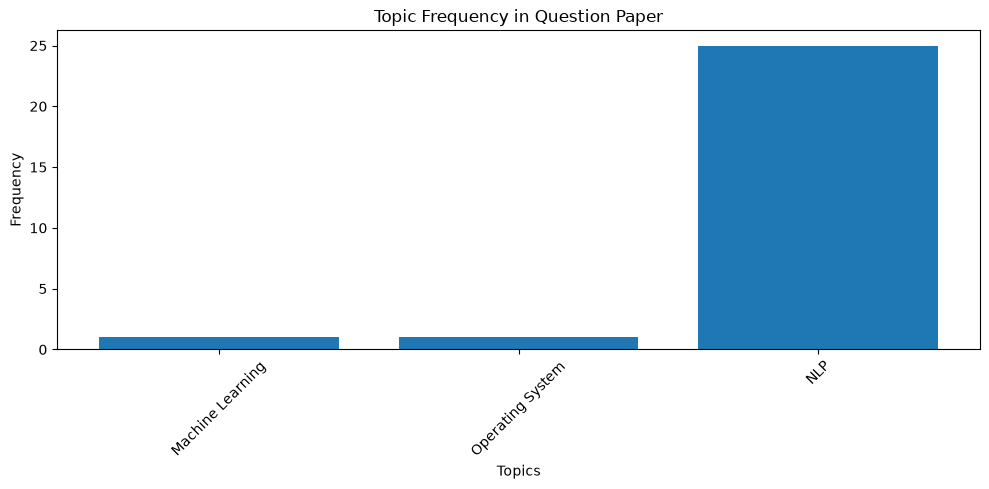

In [14]:
import matplotlib.pyplot as plt

if topic_counts:
    plt.figure(figsize=(10, 5))
    plt.bar(topic_counts.keys(), topic_counts.values())
    plt.xlabel("Topics")
    plt.ylabel("Frequency")
    plt.title("Topic Frequency in Question Paper")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No topics detected.")
    

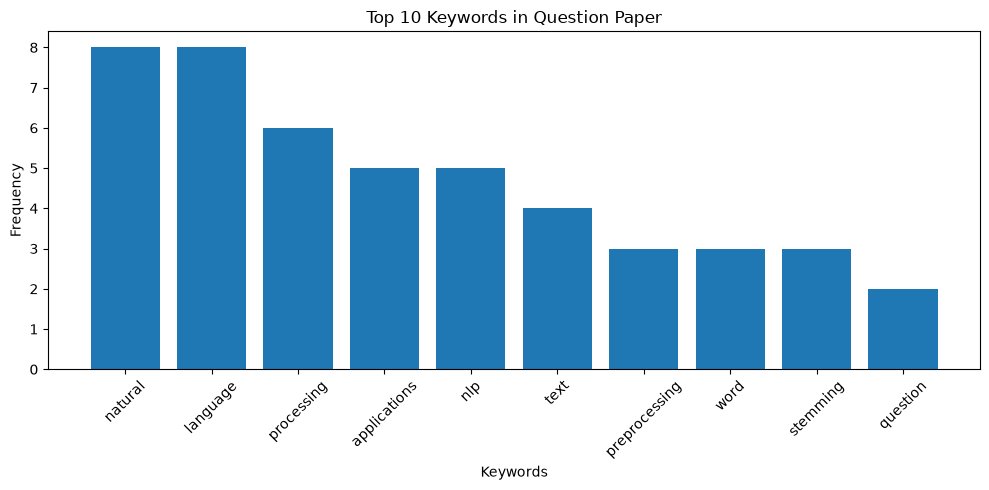

In [15]:
top_keywords = frequency.most_common(10)

words = [item[0] for item in top_keywords]
counts = [item[1] for item in top_keywords]

plt.figure(figsize=(10, 5))
plt.bar(words, counts)
plt.xlabel("Keywords")
plt.ylabel("Frequency")
plt.title("Top 10 Keywords in Question Paper")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Results

The Smart Question Paper Analyzer successfully processes the question paper using NLP techniques.

The system performs the following tasks:

- Text preprocessing and cleaning
- Tokenization
- Stopword removal
- Keyword frequency analysis
- Question extraction
- Similar question detection
- Topic identification
- Keyword and topic visualization

## Conclusion

The project demonstrates how Natural Language Processing can be used to analyze question papers automatically. It helps identify important keywords, topics, question patterns, and similar questions. The analysis can help students and teachers understand the structure and content of a question paper more efficiently.